In [1]:
using Revise
using SSMCMain.ModifiedMiCRM.MinimalModelV2

┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Symbolics → SymbolicsForwardDiffExt
│  └─ Symbolics → SymbolicsPreallocationToolsExt
│ Precompilation will also be skipped for the following, which depend on the above cycle:
│   SSMC
│   MLSolver
└ @ Pkg.API.Precompilation ~/.julia/juliaup/julia-1.10.10+0.x64.linux.gnu/share/julia/stdlib/v1.10/Pkg/src/precompilation.jl:583
Precompiling packages...
  31660.9 ms  ✓ SSMCMain
  1 dependency successfully precompiled in 38 seconds. 540 already precompiled. 4 skipped due to circular dependency.


In [2]:
using Base.Threads, OhMyThreads
using ProgressMeter
using JLD2
using Geppetto
using DataFrames
using DataFramesMeta
using HypothesisTests


In [3]:
includet("../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

# Setup

In [36]:
function plot_spatial_fs!(gl, fs, S, dx; kwargs...)
    SpM = size(fs, 1)
    M = SpM - S
    sN = size(fs, 2)
    
    ax1 = Axis(gl[1,1];
        # xlabel=L"\text{Space}",
        ylabel="Strain\nbiomass",
        xlabelsize=8fontsize_pt,
        ylabelsize=8fontsize_pt,
        xticklabelsize=6fontsize_pt,
        yticklabelsize=6fontsize_pt,
    )
    ax2 = Axis(gl[2,1];
        xlabel="Space",
        ylabel="Resource\nconcentrations",
        xlabelsize=8fontsize_pt,
        ylabelsize=8fontsize_pt,
        xticklabelsize=6fontsize_pt,
        yticklabelsize=6fontsize_pt,
    )
    
    linkxaxes!(ax1, ax2)
    hidexdecorations!(ax1; grid=false)
    rowgap!(gl, 6.)
    
    xs = ((1:sN) .- 1) .* dx;

    for i in 1:S
        lines!(ax1, xs, fs[i,:];
            color=Cycled(i),
            kwargs...
        )
    end

    for i in (S+1):SpM
        lines!(ax2, xs, fs[i,:];
            color=Cycled(-i),
            kwargs...
        )
    end

end

plot_spatial_fs! (generic function with 1 method)

# Make a big one

In [95]:
fig = Figure(;
    size=(double_col_width * 1, (double_col_width / golden_ratio) * 0.9),
);

In [96]:
f = jldopen("../../cluster_env/runs/single_influx_pdes1/rslt2_base.jld2");
df = f["df"];
md = DataFrames.metadata(df);

dx = md["L"] / md["sN"];
S = md["N"]

r = df[1,:];
fs = r.final_states;

plot_spatial_fs!(GridLayout(fig[1,1]), fs, S, dx)

In [97]:
f = jldopen("../../cluster_env/runs/rg_stevens_pdes_1/data2.jld2");

S = f["metadata"].S
dx = f["metadata"].L / f["metadata"].sN;
fs = f["sp_final_states"][33];
plot_spatial_fs!(GridLayout(fig[1,2]), fs, S, dx)

fs = f["nh_final_states"][59];
plot_spatial_fs!(GridLayout(fig[2,1]), fs, S, dx)

In [99]:
f = jldopen("../../cluster_env/runs/rg_stevens_pdes_1/data3_old.jld2");

S = f["metadata"].S
dx = f["metadata"].L / f["metadata"].sN;
fs = f["nh_final_states"][5];
plot_spatial_fs!(GridLayout(fig[2,2]), fs, S, dx)

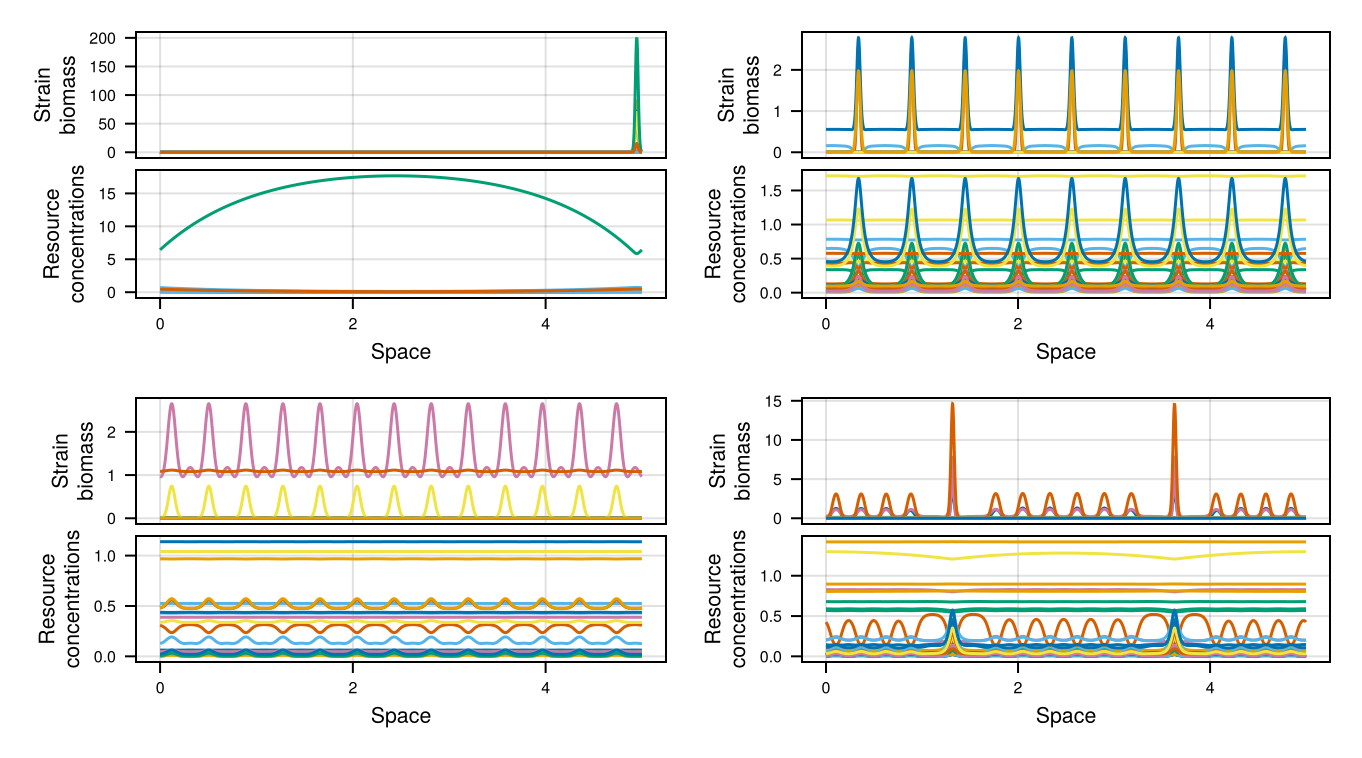

In [101]:
Makie.save("../../figures/sample_structures.pdf", fig)

fig

# Single influx sample

In [40]:
f = jldopen("../../cluster_env/runs/single_influx_pdes1/rslt2_base.jld2");
# f = jldopen("../../cluster_env/runs/single_influx_pdes1/rslt2_lowrandDr.jld2");
df = f["df"];
md = DataFrames.metadata(df);

dx = md["L"] / md["sN"];
S = md["N"]

20

r.K = 20.0


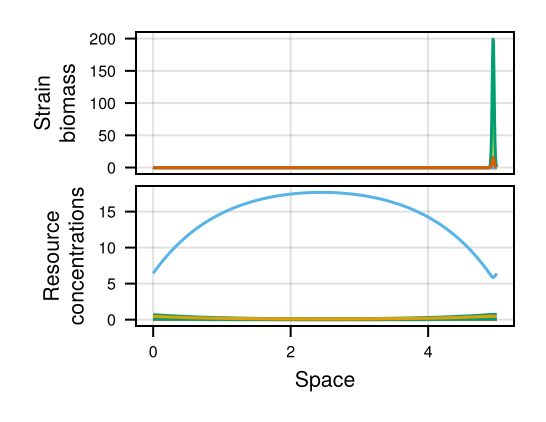

In [42]:
r = df[1,:];
@show r.K
fs = r.final_states;

fig = Figure(;
    size=(double_col_width * 0.4, (double_col_width / golden_ratio) * 0.5),
)
plot_spatial_fs!(GridLayout(fig[1,1]), fs, S, dx)
fig

In [43]:
f = jldopen("../../cluster_env/runs/single_influx_pdes1/rslt2_lowrandDr.jld2");
df = f["df"];
md = DataFrames.metadata(df);

dx = md["L"] / md["sN"];
S = md["N"]

20

r.K = 20.0


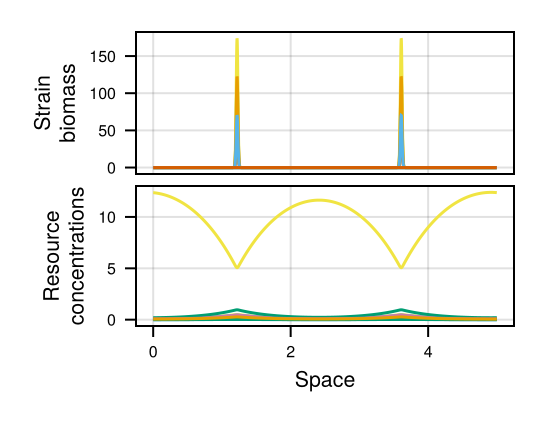

In [44]:
r = df[1,:];
@show r.K
fs = r.final_states;

fig = Figure(;
    size=(double_col_width * 0.4, (double_col_width / golden_ratio) * 0.5),
)
plot_spatial_fs!(GridLayout(fig[1,1]), fs, S, dx)
fig

# Stevens RG samples

In [71]:
f = jldopen("../../cluster_env/runs/rg_stevens_pdes_1/data2.jld2");

S = f["metadata"].S
dx = f["metadata"].L / f["metadata"].sN;
fs = f["sp_final_states"][33];

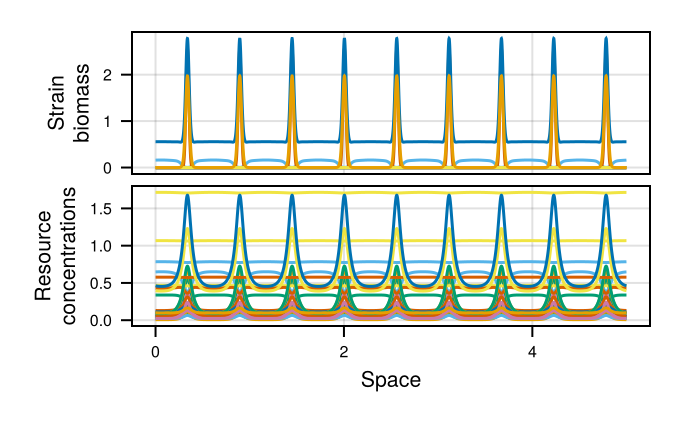

In [72]:
fig = Figure(;
    size=(double_col_width * 0.5, (double_col_width / golden_ratio) * 0.5),
)
plot_spatial_fs!(GridLayout(fig[1,1]), fs, S, dx)
fig

In [75]:
f = jldopen("../../cluster_env/runs/rg_stevens_pdes_1/data2.jld2");

S = f["metadata"].S
dx = f["metadata"].L / f["metadata"].sN;
fs = f["nh_final_states"][59];

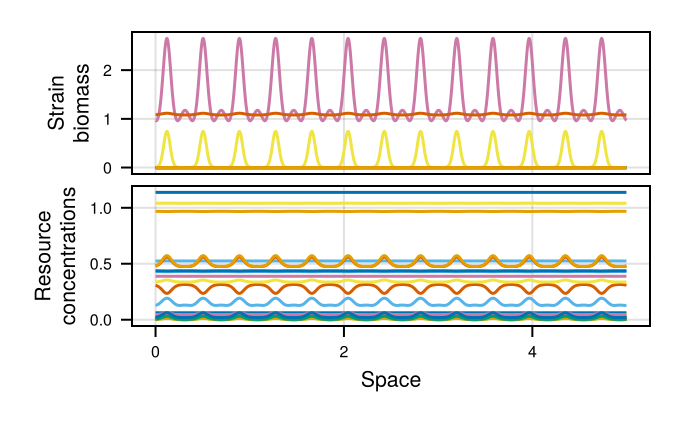

In [76]:
fig = Figure(;
    size=(double_col_width * 0.5, (double_col_width / golden_ratio) * 0.5),
)
plot_spatial_fs!(GridLayout(fig[1,1]), fs, S, dx)
fig

In [79]:
f = jldopen("../../cluster_env/runs/rg_stevens_pdes_1/data3_old.jld2");

S = f["metadata"].S
dx = f["metadata"].L / f["metadata"].sN;
fs = f["nh_final_states"][5];

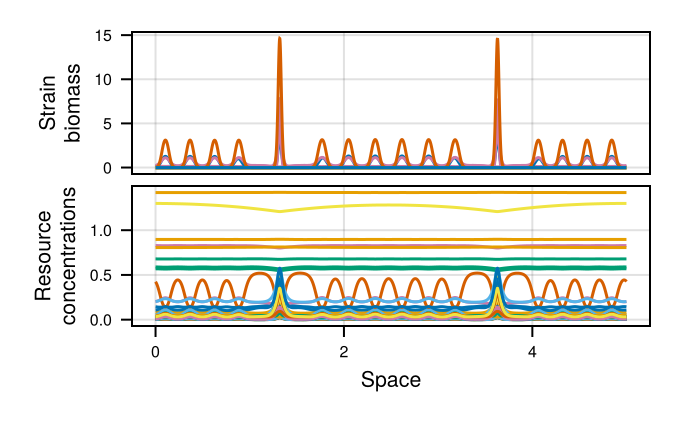

In [80]:
fig = Figure(;
    size=(double_col_width * 0.5, (double_col_width / golden_ratio) * 0.5),
)
plot_spatial_fs!(GridLayout(fig[1,1]), fs, S, dx)
fig